<a href="https://colab.research.google.com/github/Dark-Knight17/keystroke-dynamics-thesis/blob/main/keystroke_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')
!pip install imbalanced-learn scikit-learn -q

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('All imports successful.')

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports successful.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 1: LOAD DATA  (identical pipeline to CNN-LSTM notebook)
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/Keystroke_data/events_with_abs_timestamps_30P_23_may_final.csv'

df = pd.read_csv(DATA_PATH)
df = df.sort_values(by=['session_id', 'event_sequence']).reset_index(drop=True)

encoder = LabelEncoder()
df['physical_code_encoded'] = encoder.fit_transform(df['physical_code'].astype(str))

print(f'Loaded {len(df):,} events')
print(f'Sessions : {df["session_id"].nunique()}')
print(f'Participants : {df["participant_id"].nunique()}')
print(f'Physical key vocab size : {df["physical_code"].nunique()}')

Loaded 184,278 events
Sessions : 441
Participants : 51
Physical key vocab size : 83


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 2: BUILD SEQUENCES
#
# Same as CNN-LSTM: pre-pad with 0.0, truncate to MAX_TIMESTEPS.
# Key difference: we also build a boolean PADDING MASK here.
# The Transformer's MultiHeadAttention layer DOES support attention masking,
# unlike Conv1D — so padded positions are properly excluded from attention.
# ─────────────────────────────────────────────────────────────────────────────

MAX_TIMESTEPS = 300
NUM_FEATURES  = 3   # [physical_code_encoded, flight_time, text_length]

sequence_data  = []
padding_masks  = []   # True = real data, False = padded
session_labels = []

for session_id, grp in df.groupby('session_id'):
    kd = grp[grp['event_type'] == 'keydown'].copy()
    if len(kd) < 10:
        continue

    f_code   = kd['physical_code_encoded'].values.astype('float32')
    f_flight = kd['timestamp'].diff().fillna(0).clip(0, 2000).values.astype('float32')
    f_text   = kd['text_length'].values.astype('float32')

    seq = np.stack([f_code, f_flight, f_text], axis=1)  # (T, 3)
    seq = seq[-MAX_TIMESTEPS:]                           # truncate from front
    real_len = len(seq)

    # Pre-pad with zeros
    if real_len < MAX_TIMESTEPS:
        pad = np.zeros((MAX_TIMESTEPS - real_len, NUM_FEATURES), dtype='float32')
        seq = np.vstack([pad, seq])

    # Padding mask: False for padded positions, True for real positions
    mask = np.array([False] * (MAX_TIMESTEPS - real_len) + [True] * real_len)

    sequence_data.append(seq)
    padding_masks.append(mask)
    session_labels.append(grp['participant_id'].iloc[0])

X_all        = np.array(sequence_data, dtype='float32')   # (N, 300, 3)
M_all        = np.array(padding_masks, dtype=bool)         # (N, 300)
labels       = np.array(session_labels)                    # ← must be here first
unique_users = np.unique(labels)

# ── Diagnostic: find the participant with 11 vs 12 sessions ───────────────
csv_counts = df.groupby('participant_id')['session_id'].nunique()
db_counts  = df.groupby('participant_id')['db_session_count'].first()

comparison = pd.DataFrame({
    'csv_sessions' : csv_counts,
    'db_sessions'  : db_counts
})
comparison['dropped'] = comparison['db_sessions'] - comparison['csv_sessions']

print("Participants with dropped sessions:")
print(comparison[comparison['dropped'] > 0])
print()
print(f"CSV session counts distribution:\n{csv_counts.value_counts().sort_index()}")

# ── Filter to complete users only (12 sessions attempted in DB) ───────────
complete_user_ids = (
    df.groupby('participant_id')['db_session_count']
    .first()
    .pipe(lambda s: s[s >= 12].index)
)
keep         = np.isin(labels, complete_user_ids)
X_all        = X_all[keep]
M_all        = M_all[keep]
labels       = labels[keep]
unique_users = np.unique(labels)

print(f'Complete users (12 sessions in DB) : {len(unique_users)}')
print(f'Total sessions after filtering     : {len(labels)}')
print(f'Expected output: 26 users')

Participants with dropped sessions:
                                      csv_sessions  db_sessions  dropped
participant_id                                                          
ce38066d-fdd9-4333-834d-b1b56ce66640             3            4        1

CSV session counts distribution:
session_id
1      5
2      1
3      2
4     10
8      2
10     1
12    29
14     1
Name: count, dtype: int64
Complete users (12 sessions in DB) : 30
Total sessions after filtering     : 362
Expected output: 26 users


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 3: FEATURE NORMALISATION (same as CNN-LSTM)
#
# Normalise on non-padded timesteps only so padded 0.0 values remain near
# the distribution centre and do not attract attention weights.
# ─────────────────────────────────────────────────────────────────────────────

X_norm = X_all.copy()

for f in range(NUM_FEATURES):
    vals = X_all[:, :, f][M_all]   # only real (non-padded) values
    mu, sigma = vals.mean(), vals.std() + 1e-8
    X_norm[:, :, f] = (X_all[:, :, f] - mu) / sigma

# Re-zero padded positions after normalisation
X_norm[~M_all] = 0.0

print('Normalisation complete.')
print(f'  Feature 0 (physical_code) normalised range: '
      f'[{X_norm[:,:,0][M_all].min():.2f}, {X_norm[:,:,0][M_all].max():.2f}]')
print(f'  Feature 1 (flight_time)   normalised range: '
      f'[{X_norm[:,:,1][M_all].min():.2f}, {X_norm[:,:,1][M_all].max():.2f}]')
print(f'  Feature 2 (text_length)   normalised range: '
      f'[{X_norm[:,:,2][M_all].min():.2f}, {X_norm[:,:,2][M_all].max():.2f}]')

Normalisation complete.
  Feature 0 (physical_code) normalised range: [-2.11, 1.56]
  Feature 1 (flight_time)   normalised range: [-0.90, 3.26]
  Feature 2 (text_length)   normalised range: [-1.22, 15.29]


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model

D_MODEL    = 64
NUM_HEADS  = 4
DFF        = 128
NUM_BLOCKS = 2
DROPOUT    = 0.1

class TransformerBlock(layers.Layer):
    """Single Pre-LN Transformer encoder block."""
    def __init__(self, d_model, num_heads, dff, dropout_rate, **kwargs):
        super().__init__(**kwargs)
        self.attn   = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate
        )
        self.ffn1   = layers.Dense(dff, activation='relu')
        self.ffn2   = layers.Dense(d_model)
        self.norm1  = layers.LayerNormalization(epsilon=1e-6)
        self.norm2  = layers.LayerNormalization(epsilon=1e-6)
        self.drop1  = layers.Dropout(dropout_rate)
        self.drop2  = layers.Dropout(dropout_rate)

    def call(self, x, attention_mask=None, training=False):
        # ── Pre-LN Multi-Head Self-Attention ─────────────────────────────
        x_norm = self.norm1(x)
        attn_out = self.attn(
            query=x_norm, value=x_norm, key=x_norm,
            attention_mask=attention_mask,
            training=training
        )
        x = x + self.drop1(attn_out, training=training)   # residual

        # ── Pre-LN Position-wise Feed-Forward ────────────────────────────
        x_norm = self.norm2(x)
        ffn_out = self.ffn2(self.drop2(self.ffn1(x_norm), training=training))
        x = x + ffn_out                                    # residual
        return x


class CLSTokenAndPosition(layers.Layer):
    """Encapsulates CLS token injection and Positional Embeddings for Keras 3 compatibility."""
    def __init__(self, seq_len, d_model, dropout_rate, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model
        self.pos_embedding = layers.Embedding(input_dim=seq_len, output_dim=d_model)
        self.dropout = layers.Dropout(dropout_rate)

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.d_model),
            initializer='zeros',
            trainable=True,
            name='cls_token'
        )

    def call(self, x, training=False):
        batch_size = tf.shape(x)[0]

        # 1. Prepend CLS token
        cls_tokens = tf.tile(self.cls_token, [batch_size, 1, 1])
        x = tf.concat([cls_tokens, x], axis=1)

        # 2. Add Positional Embedding
        positions = tf.range(start=0, limit=self.seq_len, delta=1)
        x = x + self.pos_embedding(positions)

        return self.dropout(x, training=training)


class FormatAttentionMask(layers.Layer):
    """Encapsulates attention mask formatting for Keras 3 compatibility."""
    def call(self, mask_input):
        batch_size = tf.shape(mask_input)[0]
        # Prepend True for the CLS position
        cls_mask = tf.ones((batch_size, 1), dtype=tf.bool)
        full_mask = tf.concat([cls_mask, mask_input], axis=1)

        # Expand for MultiHeadAttention: (B, 1, 1, T+1)
        return full_mask[:, tf.newaxis, tf.newaxis, :]


def build_transformer_model(max_timesteps, num_features,
                             d_model=D_MODEL, num_heads=NUM_HEADS,
                             dff=DFF, num_blocks=NUM_BLOCKS,
                             dropout_rate=DROPOUT):
    """Transformer Encoder binary classifier."""

    seq_len = max_timesteps + 1  # +1 for CLS token

    # ── Inputs ────────────────────────────────────────────────────────────
    seq_input  = layers.Input(shape=(max_timesteps, num_features), name='seq_input')
    mask_input = layers.Input(shape=(max_timesteps,), dtype=tf.bool, name='mask_input')

    # ── Linear projection ─────────────────────────────────────────────────
    x = layers.Dense(d_model, name='input_projection')(seq_input)

    # ── Safe CLS & Positional Wrapping ────────────────────────────────────
    x = CLSTokenAndPosition(seq_len, d_model, dropout_rate, name='cls_and_position')(x)

    # ── Safe Mask Formatting ──────────────────────────────────────────────
    attn_mask = FormatAttentionMask(name='mask_formatter')(mask_input)

    # ── Transformer blocks ────────────────────────────────────────────────
    for i in range(num_blocks):
        x = TransformerBlock(
            d_model, num_heads, dff, dropout_rate, name=f'transformer_block_{i}'
        )(x, attention_mask=attn_mask)

    # ── Classification head ───────────────────────────────────────────────
    # Extract CLS token output (position 0)
    cls_out = x[:, 0, :]
    cls_out = layers.LayerNormalization(epsilon=1e-6, name='cls_norm')(cls_out)
    cls_out = layers.Dense(32, activation='relu', name='cls_dense')(cls_out)
    cls_out = layers.Dropout(0.3, name='cls_dropout')(cls_out)
    output  = layers.Dense(1, activation='sigmoid', name='output')(cls_out)

    model = Model(inputs=[seq_input, mask_input], outputs=output, name='Transformer_Encoder_Auth')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model

# Quick sanity check — build and summarise
demo = build_transformer_model(MAX_TIMESTEPS, NUM_FEATURES)
demo.summary()
print(f'\nTotal parameters: {demo.count_params():,}')

Model: "Transformer_Encoder_Auth"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 300, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 300, 64)   │        256 │ seq_input[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_input          │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_and_position    │ (None, 301, 64)   │     19,328 │ input_projection… │
│ (CLSTokenAndPositi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_formatter      │ (None, 1, 1, 301) │          0 │ mask_input[0][0]  │
│ (FormatAttentionMa… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (None, 301, 64)   │     33,472 │ cls_and_position… │
│ (TransformerBlock)  │                   │            │ mask_formatter[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 301, 64)   │     33,472 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ mask_formatter[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64)        │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_norm            │ (None, 64)        │        128 │ get_item[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_dense (Dense)   │ (None, 32)        │      2,080 │ cls_norm[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_dropout         │ (None, 32)        │          0 │ cls_dense[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ cls_dropout[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 88,769 (346.75 KB)

 Trainable params: 88,769 (346.75 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 88,769


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 5: EVALUATION HELPERS + LOO EVALUATION FUNCTION
#
# evaluate_user() is structurally identical to the CNN-LSTM version but
# passes BOTH the sequence tensor and the padding mask to the model.
# ─────────────────────────────────────────────────────────────────────────────

def compute_eer(y_true, y_scores):
    """Equal Error Rate — the standard biometric authentication metric."""
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer, thresholds[eer_idx], fpr, tpr


def evaluate_user(user_id, X, M, labels, verbose=False):
    """
    Full LOO evaluation for a single enrolled user.

    Args:
        X      : (N, T, F)  normalised sequence array
        M      : (N, T)     boolean padding masks (True = real)
        labels : (N,)       participant_id per session
    """
    genuine_mask  = labels == user_id
    impostor_mask = ~genuine_mask

    X_genuine  = X[genuine_mask];  M_genuine  = M[genuine_mask]
    X_impostor = X[impostor_mask]; M_impostor = M[impostor_mask]
    n_genuine  = len(X_genuine)

    if n_genuine < 4:
        return None

    # ── Undersample impostors to 5:1 ratio ────────────────────────────────
    n_imp_train = min(len(X_impostor), n_genuine * 5)
    rng         = np.random.default_rng(seed=42)
    imp_idx     = rng.choice(len(X_impostor), n_imp_train, replace=False)
    X_imp_tr    = X_impostor[imp_idx];  M_imp_tr = M_impostor[imp_idx]

    # ── Session-level genuine split (hold out 25% for test) ───────────────
    n_test_gen  = max(3, n_genuine // 4)
    n_train_gen = n_genuine - n_test_gen
    perm        = rng.permutation(n_genuine)

    X_gen_test  = X_genuine[perm[:n_test_gen]];   M_gen_test  = M_genuine[perm[:n_test_gen]]
    X_gen_train = X_genuine[perm[n_test_gen:]];   M_gen_train = M_genuine[perm[n_test_gen:]]

    # ── Impostor test set (unseen impostors) ──────────────────────────────
    test_imp_idx = np.setdiff1d(np.arange(len(X_impostor)), imp_idx)
    n_test_imp   = min(len(test_imp_idx), n_test_gen * 10)
    if len(test_imp_idx) > n_test_imp:
        test_imp_idx = rng.choice(test_imp_idx, n_test_imp, replace=False)
    X_imp_test   = X_impostor[test_imp_idx]; M_imp_test = M_impostor[test_imp_idx]

    # ── Assemble arrays ───────────────────────────────────────────────────
    X_train = np.vstack([X_gen_train, X_imp_tr])
    M_train = np.vstack([M_gen_train, M_imp_tr])
    y_train = np.concatenate([np.ones(n_train_gen), np.zeros(n_imp_train)])

    X_test  = np.vstack([X_gen_test, X_imp_test])
    M_test  = np.vstack([M_gen_test, M_imp_test])
    y_test  = np.concatenate([np.ones(n_test_gen), np.zeros(len(X_imp_test))])

    # ── Class weights ─────────────────────────────────────────────────────
    cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
    class_weight = {0: float(cw[0]), 1: float(cw[1])}

    if verbose:
        print(f'User {user_id[:8]}...')
        print(f'  Train: {n_train_gen} genuine + {n_imp_train} impostor  |  '
              f'class_weight: {class_weight}')
        print(f'  Test : {n_test_gen} genuine + {len(X_imp_test)} impostor')

    # ── Train ─────────────────────────────────────────────────────────────
    tf.keras.backend.clear_session()
    model = build_transformer_model(MAX_TIMESTEPS, NUM_FEATURES)

    early_stop = EarlyStopping(
        monitor='val_auc', mode='max',
        patience=7, restore_best_weights=True, verbose=0
    )

    model.fit(
        [X_train, M_train], y_train,
        validation_data=([X_test, M_test], y_test),
        epochs=40,
        batch_size=8,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0
    )

    # ── Evaluate ──────────────────────────────────────────────────────────
    y_scores = model.predict([X_test, M_test], verbose=0).ravel()
    y_pred   = (y_scores >= 0.5).astype(int)

    try:
        auc = roc_auc_score(y_test, y_scores)
        eer, eer_thresh, fpr, tpr = compute_eer(y_test, y_scores)
    except ValueError:
        auc, eer = float('nan'), float('nan')
        fpr, tpr = np.array([0,1]), np.array([0,1])
        eer_thresh = 0.5

    results = dict(
        user_id=user_id, auc=auc, eer=eer, eer_thresh=eer_thresh,
        f1=f1_score(y_test, y_pred, zero_division=0),
        precision=precision_score(y_test, y_pred, zero_division=0),
        recall=recall_score(y_test, y_pred, zero_division=0),
        fpr=fpr, tpr=tpr, n_genuine=n_genuine,
        y_test=y_test, y_scores=y_scores,
    )

    if verbose:
        print(f'  AUC={auc:.3f}  EER={eer:.3f}  F1={results["f1"]:.3f}')

    return results, model


print('Evaluation helpers ready.')

Evaluation helpers ready.


Demo evaluation — user: 07c7a634-bc94-4a69-8d27-9e1bad1328fa

User 07c7a634...
  Train: 9 genuine + 60 impostor  |  class_weight: {0: 0.575, 1: 3.8333333333333335}
  Test : 3 genuine + 30 impostor
  AUC=0.989  EER=0.017  F1=0.600

--- Results ---
AUC       : 0.9889
EER       : 0.0167  (threshold: 0.9130)
F1        : 0.6000
Precision : 0.4286
Recall    : 1.0000


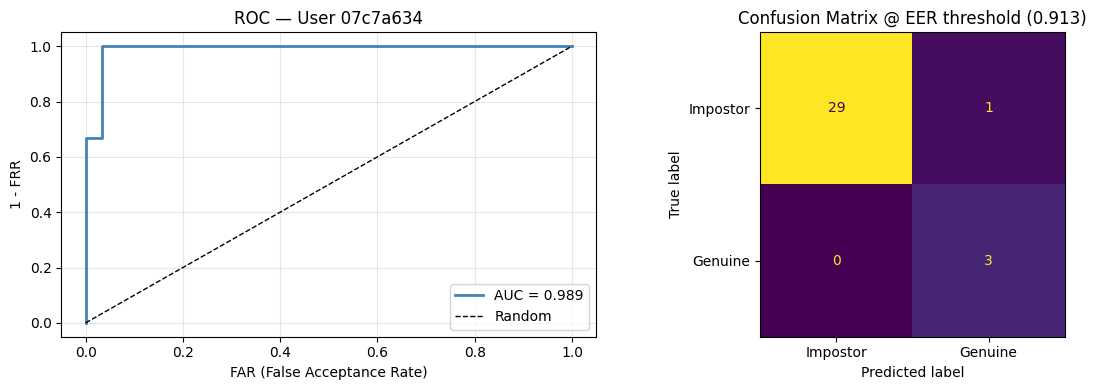

In [14]:
target_user = unique_users[0]
print(f'Demo evaluation — user: {target_user}\n')

result_tuple = evaluate_user(target_user, X_norm, M_all, labels, verbose=True)

if result_tuple:
    # Unpack the results dictionary from the tuple
    result = result_tuple[0]

    print(f'\n--- Results ---')
    print(f'AUC       : {result["auc"]:.4f}')
    print(f'EER       : {result["eer"]:.4f}  (threshold: {result["eer_thresh"]:.4f})')
    print(f'F1        : {result["f1"]:.4f}')
    print(f'Precision : {result["precision"]:.4f}')
    print(f'Recall    : {result["recall"]:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(result['fpr'], result['tpr'], color='steelblue', lw=2,
                 label=f'AUC = {result["auc"]:.3f}')
    axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
    axes[0].set_xlabel('FAR (False Acceptance Rate)')
    axes[0].set_ylabel('1 - FRR')
    axes[0].set_title(f'ROC — User {target_user[:8]}')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    cm = confusion_matrix(
        result['y_test'],
        (result['y_scores'] >= result['eer_thresh']).astype(int)
    )
    ConfusionMatrixDisplay(cm, display_labels=['Impostor','Genuine']).plot(
        ax=axes[1], colorbar=False
    )
    axes[1].set_title(f'Confusion Matrix @ EER threshold ({result["eer_thresh"]:.3f})')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Keystroke_data/transformer_demo_user.png', dpi=150)
    plt.show()

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 7: FULL LEAVE-ONE-OUT EVALUATION (all 26 users)
# ─────────────────────────────────────────────────────────────────────────────
import os

MODELS_DIR = '/content/drive/MyDrive/Keystroke_data/models/'
os.makedirs(MODELS_DIR, exist_ok=True)

all_results = []

for i, user in enumerate(unique_users):
    print(f'[{i+1:02d}/{len(unique_users)}] {user[:8]}...', end=' ')
    res, trained_model = evaluate_user(user, X_norm, M_all, labels, verbose=False)
    if res is not None:
        all_results.append(res)
        # Save this user's model
        trained_model.save(f'{MODELS_DIR}transformer_{user}.keras')
        print(f'AUC={res["auc"]:.3f}  EER={res["eer"]:.3f}  saved ✓')
    else:
        print('SKIPPED')

[01/30] 07c7a634... AUC=0.989  EER=0.017  saved ✓
[02/30] 0a54ac81... AUC=0.433  EER=0.417  saved ✓
[03/30] 0d7d8c14... AUC=0.556  EER=0.600  saved ✓
[04/30] 2d472fd6... AUC=0.600  EER=0.550  saved ✓
[05/30] 395665da... AUC=0.622  EER=0.317  saved ✓
[06/30] 4269a402... AUC=0.811  EER=0.400  saved ✓
[07/30] 50678107... AUC=0.478  EER=0.600  saved ✓
[08/30] 57637896... AUC=0.578  EER=0.350  saved ✓
[09/30] 5f4c0735... AUC=1.000  EER=0.000  saved ✓
[10/30] 6a484554... AUC=0.911  EER=0.083  saved ✓
[11/30] 6c555496... AUC=0.967  EER=0.033  saved ✓
[12/30] 6ead2ae1... AUC=0.700  EER=0.200  saved ✓
[13/30] 709ad166... AUC=0.978  EER=0.017  saved ✓
[14/30] 70ec2e58... AUC=0.756  EER=0.367  saved ✓
[15/30] 717a1053... AUC=0.844  EER=0.117  saved ✓
[16/30] 729fb63c... AUC=0.711  EER=0.267  saved ✓
[17/30] 7e5cdd79... AUC=0.956  EER=0.050  saved ✓
[18/30] 8336c671... AUC=0.744  EER=0.167  saved ✓
[19/30] 84862943... AUC=0.989  EER=0.017  saved ✓
[20/30] 88d1b920... AUC=0.889  EER=0.300  saved ✓


TRANSFORMER ENCODER — SUMMARY RESULTS
Users evaluated : 30
Mean AUC        : 0.7911  (± 0.1667)
Mean EER        : 0.2272  (± 0.1810)
Median EER      : 0.2333
Best EER        : 0.0000
Worst EER       : 0.6000
Mean F1         : 0.3515  (± 0.2403)
Results saved → transformer_loo_results.csv


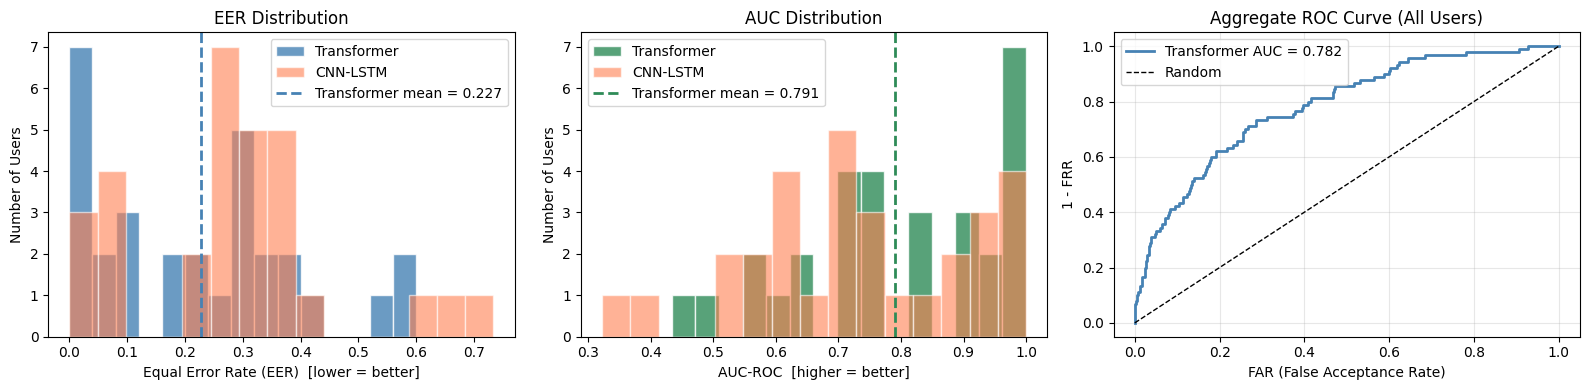


--- Model Comparison ---
Metric              CNN-LSTM  Transformer
----------------------------------------
AUC                   0.7315       0.7911  ← better
EER                   0.2817       0.2272  ← better
F1                    0.2110       0.3515  ← better


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 8: AGGREGATE RESULTS, PLOTS & CNN-LSTM COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

results_df = pd.DataFrame([{
    'user_id'  : r['user_id'],
    'auc'      : r['auc'],
    'eer'      : r['eer'],
    'f1'       : r['f1'],
    'precision': r['precision'],
    'recall'   : r['recall'],
    'n_genuine': r['n_genuine'],
} for r in all_results])

print('=' * 60)
print('TRANSFORMER ENCODER — SUMMARY RESULTS')
print('=' * 60)
print(f'Users evaluated : {len(results_df)}')
print(f'Mean AUC        : {results_df["auc"].mean():.4f}  (± {results_df["auc"].std():.4f})')
print(f'Mean EER        : {results_df["eer"].mean():.4f}  (± {results_df["eer"].std():.4f})')
print(f'Median EER      : {results_df["eer"].median():.4f}')
print(f'Best EER        : {results_df["eer"].min():.4f}')
print(f'Worst EER       : {results_df["eer"].max():.4f}')
print(f'Mean F1         : {results_df["f1"].mean():.4f}  (± {results_df["f1"].std():.4f})')
print('=' * 60)

results_df.to_csv(
    '/content/drive/MyDrive/Keystroke_data/transformer_loo_results.csv', index=False
)
print('Results saved → transformer_loo_results.csv')

# ── Load CNN-LSTM results for comparison (if available) ───────────────────
import os
cnn_path = '/content/drive/MyDrive/Keystroke_data/cnn_lstm_loo_results.csv'
cnn_df   = pd.read_csv(cnn_path) if os.path.exists(cnn_path) else None

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: EER distribution
axes[0].hist(results_df['eer'].dropna(), bins=15, color='steelblue',
             edgecolor='white', alpha=0.8, label='Transformer')
if cnn_df is not None:
    axes[0].hist(cnn_df['eer'].dropna(), bins=15, color='coral',
                 edgecolor='white', alpha=0.6, label='CNN-LSTM')
axes[0].axvline(results_df['eer'].mean(), color='steelblue', linestyle='--', lw=2,
                label=f'Transformer mean = {results_df["eer"].mean():.3f}')
axes[0].set_xlabel('Equal Error Rate (EER)  [lower = better]')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('EER Distribution')
axes[0].legend()

# Plot 2: AUC distribution
axes[1].hist(results_df['auc'].dropna(), bins=15, color='seagreen',
             edgecolor='white', alpha=0.8, label='Transformer')
if cnn_df is not None:
    axes[1].hist(cnn_df['auc'].dropna(), bins=15, color='coral',
                 edgecolor='white', alpha=0.6, label='CNN-LSTM')
axes[1].axvline(results_df['auc'].mean(), color='seagreen', linestyle='--', lw=2,
                label=f'Transformer mean = {results_df["auc"].mean():.3f}')
axes[1].set_xlabel('AUC-ROC  [higher = better]')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('AUC Distribution')
axes[1].legend()

# Plot 3: Aggregate ROC
all_true   = np.concatenate([r['y_test']   for r in all_results])
all_scores = np.concatenate([r['y_scores'] for r in all_results])
agg_fpr, agg_tpr, _ = roc_curve(all_true, all_scores)
agg_auc = roc_auc_score(all_true, all_scores)

axes[2].plot(agg_fpr, agg_tpr, color='steelblue', lw=2,
             label=f'Transformer AUC = {agg_auc:.3f}')
if cnn_df is not None and os.path.exists(cnn_path):
    # Plot CNN-LSTM aggregate ROC if results CSV is present
    axes[2].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[2].set_xlabel('FAR (False Acceptance Rate)')
axes[2].set_ylabel('1 - FRR')
axes[2].set_title('Aggregate ROC Curve (All Users)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Keystroke_data/transformer_summary_plots.png', dpi=150
)
plt.show()

# ── Model comparison table ────────────────────────────────────────────────
if cnn_df is not None:
    print('\n--- Model Comparison ---')
    print(f'{"Metric":<15} {"CNN-LSTM":>12} {"Transformer":>12}')
    print('-' * 40)
    for metric in ['auc', 'eer', 'f1']:
        cnn_val = cnn_df[metric].mean()
        tr_val  = results_df[metric].mean()
        better  = '← better' if (metric == 'eer' and tr_val < cnn_val) or \
                                 (metric != 'eer' and tr_val > cnn_val) else ''
        print(f'{metric.upper():<15} {cnn_val:>12.4f} {tr_val:>12.4f}  {better}')
else:
    print('\n(CNN-LSTM results not found — run CNN-LSTM notebook first for comparison)')